In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
import random

In [ ]:
def train(positive_examples, negative_examples, num_iterations = 100):
    num_dims = positive_examples.shape[1]
    weights = np.zeros((num_dims,1)) # initialise weights to zero (perceptron starts with no knowledge of the data)
    
    pos_count = positive_examples.shape[0] # total number of positive examples
    neg_count = negative_examples.shape[0] # total number of negative examples
    
    report_frequency = 10 # N interations (how often to print progress)
    
    for i in range(num_iterations):
        pos = random.choice(positive_examples) # random selection of a positive example for this round of training
        neg = random.choice(negative_examples) # random selection of a negative example for this round of training

        z = np.dot(pos, weights) # computes wᵀx (weighted sum) for positive example
        if z < 0: # misclassified: postive example scored negative
            weights = weights + pos.reshape(weights.shape) # weight update rule for positive example: w + ηxᵢtᵢ

        z  = np.dot(neg, weights) # computes wᵀx (weighted sum) for negative example
        if z >= 0: # misclassified: negative example scored positive
            weights = weights - neg.reshape(weights.shape) # weight update rule for negative example: w - ηxᵢtᵢ
            
        if i % report_frequency == 0:             
            pos_out = np.dot(positive_examples, weights) # scores for all positive examples
            neg_out = np.dot(negative_examples, weights) # scores for all negative examples
            pos_correct = (pos_out >= 0).sum() / float(pos_count) # % of positive examples correctly classified: scored ≥0
            neg_correct = (neg_out < 0).sum() / float(neg_count) # % of negative examples correctly classified: scored <0
            print("Iteration={}, pos correct={}, neg correct={}".format(i,pos_correct,neg_correct))

    return weights

In [ ]:
def accuracy(weights, test_x, test_labels):
    res = np.dot(np.c_[test_x,np.ones(len(test_x))],weights)
    return (res.reshape(test_labels.shape)*test_labels>=0).sum()/float(len(test_labels))

In [22]:
# Using Python's urllib/gzip instead of wget/gzip shell commands,
# since wget is not available by default on Windows
import urllib.request
import gzip
import shutil

url = "https://github.com/mnielsen/neural-networks-and-deep-learning/raw/master/data/mnist.pkl.gz"

urllib.request.urlretrieve(url, "mnist.pkl.gz")

with gzip.open("mnist.pkl.gz", "rb") as f_in:
    with open("mnist.pkl", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Done — mnist.pkl is ready")

Done — mnist.pkl is ready


In [29]:
with open("mnist.pkl", "rb") as mnist_pickle:
    raw_data = pickle.load(mnist_pickle, encoding='latin1') # Added encoding='latin1' to fix a Python 2 vs Python 3 pickle compatibility issue

In [30]:
# The downloaded pickle file uses the (train, valid, test) tuple format,
# not the {'Train': {...}, 'Test': {...}} dict format this notebook expects.
# Manually reconstructing the expected dictionary structure here.
training_data, validation_data, test_data = raw_data

MNIST = {
    'Train': {
        'Features': training_data[0],
        'Labels': training_data[1]
    },
    'Test': {
        'Features': test_data[0],
        'Labels': test_data[1]
    }
}

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01171875 0.0703125
 0.0703125  0.0703125  0.4921875  0.53125    0.68359375 0.1015625
 0.6484375  0.99609375 0.96484375 0.49609375 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.1171875  0.140625
 0.3671875  0.6015625 ]
5


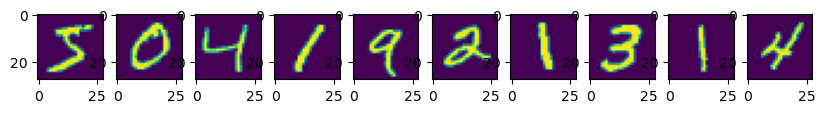

In [31]:
print(MNIST['Train']['Features'][0][130:180])
print(MNIST['Train']['Labels'][0])
features = MNIST['Train']['Features'].astype(np.float32) / 256.0
labels = MNIST['Train']['Labels']
fig = plt.figure(figsize=(10,5))
for i in range(10):
    ax = fig.add_subplot(1,10,i+1)
    plt.imshow(features[i].reshape(28,28))
plt.show()

In [34]:
# Create 10 one-vs-all datasets for all digits
def set_mnist_pos_neg_1vsall(positive_label):
    positive_indices = [i for i, j in enumerate(MNIST['Train']['Labels']) 
                          if j == positive_label]
    negative_indices = [i for i, j in enumerate(MNIST['Train']['Labels']) 
                          if j != positive_label]

    positive_images = MNIST['Train']['Features'][positive_indices]
    negative_images = MNIST['Train']['Features'][negative_indices]

    return positive_images, negative_images

datasets = {}

for digit in range(10):
    pos, neg = set_mnist_pos_neg_1vsall(digit)
    datasets[digit] = (pos, neg)

In [35]:
# Train 10 perceptrons
weights = {}

for digit in range(10):
    pos, neg = datasets[digit]
    print(f"Training perceptron for digit {digit}...")
    weights[digit] = train(pos, neg, num_iterations=1000)

Training perceptron for digit 0...
Iteration=0, pos correct=0.0, neg correct=1.0
Iteration=10, pos correct=0.9892538523925385, neg correct=0.6894470577793557
Iteration=20, pos correct=0.9681670721816708, neg correct=0.8436584716428508
Iteration=30, pos correct=0.8331305758313058, neg correct=0.9682479808289696
Iteration=40, pos correct=0.9856042173560422, neg correct=0.74691577172273
Iteration=50, pos correct=0.9274128142741281, neg correct=0.909891719179906
Iteration=60, pos correct=0.9562043795620438, neg correct=0.9193441022454957
Iteration=70, pos correct=0.8915247364152473, neg correct=0.9777447412798438
Iteration=80, pos correct=0.8915247364152473, neg correct=0.9777447412798438
Iteration=90, pos correct=0.9740470397404704, neg correct=0.9142850803230673
Iteration=100, pos correct=0.9057177615571776, neg correct=0.9850448211591373
Iteration=110, pos correct=0.986212489862125, neg correct=0.8045841838998846
Iteration=120, pos correct=0.9318734793187348, neg correct=0.9724638324309

In [ ]:
# Define classify function to perform digit classification using one matrix multiplication.
def classify_fast(x):
    scores = [np.dot(x, np.hstack([weights[digit]])) for digit in range(10)]
    return np.argmax(scores)

In [ ]:
# Measure the accuracy of classification and print confusion matrix
def evaluate(feature_set, label_set):
    predictions = np.array([classify_fast(x) for x in feature_set])
    accuracy = (predictions == label_set).mean()
    
    confusion = np.zeros((10, 10), dtype=int)
    for true_label, pred_label in zip(label_set, predictions):
        confusion[true_label][pred_label] += 1
    
    return accuracy, confusion

In [ ]:
# Claude generated code to evaluate the model on both training and test datasets, and print the results.
test_features = MNIST['Test']['Features'].astype(np.float32) / 256.0
test_labels = MNIST['Test']['Labels']

train_acc, train_confusion = evaluate(features, labels)
test_acc, test_confusion = evaluate(test_features, test_labels)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)
print("Confusion matrix (test):")
print(test_confusion)

Train accuracy: 0.8294
Test accuracy: 0.8466
Confusion matrix (test):
[[ 910    0    1    5    1   27   19    1   16    0]
 [   0 1106    6    5    3    1    9    3    2    0]
 [   6    6  879   13   15    6   30   25   47    5]
 [   3    0   44  873    1   29   14   20   19    7]
 [   1    0    9    0  832    1    7    4   26  102]
 [  12    2    2   90   16  616   42   19   85    8]
 [  10    0    5    1   25   25  882    1    9    0]
 [   6    8   22    5   15    0    4  928    3   37]
 [   8   22   21   58   21   77   24   34  702    7]
 [  12    5    7   14   93    6    2   91   41  738]]
